### Domain –Retail
### Focus –Visualize the sales data

#### Business challenge/requirement
##### BigMart is one of the biggest retailers in Europe and has operations across multiple countries. You are a data analyst in the IT team of BigMart.
##### Invoice and SKU wise sales data for the Year 2011 is shared with you.
##### You need to prepare meaningful charts to showcase the various sales trends for 2011 to top management.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
bm_df = pd.read_csv('./requirements/BigMartSalesData.csv')
bm_df.info()
bm_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541874 entries, 0 to 541873
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541874 non-null  object 
 1   StockCode    541874 non-null  object 
 2   Description  540422 non-null  object 
 3   Quantity     541874 non-null  int64  
 4   UnitPrice    541874 non-null  float64
 5   Amount       541874 non-null  float64
 6   InvoiceDate  541874 non-null  object 
 7   Day          541874 non-null  int64  
 8   Month        541874 non-null  int64  
 9   Year         541874 non-null  int64  
 10  CustomerID   406829 non-null  float64
 11  Country      541874 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 49.6+ MB


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Amount,InvoiceDate,Day,Month,Year,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,01-12-10,1,12,2010,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,3.39,20.34,01-12-10,1,12,2010,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,01-12-10,1,12,2010,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,01-12-10,1,12,2010,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,01-12-10,1,12,2010,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...,...
541869,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,10.20,09-12-11,9,12,2011,12680.0,France
541870,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12.60,09-12-11,9,12,2011,12680.0,France
541871,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,16.60,09-12-11,9,12,2011,12680.0,France
541872,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,16.60,09-12-11,9,12,2011,12680.0,France


#### Plot total sales per month for the Year 2011. How have the total sales increased over the months in the Year 2011? Which month has the lowest sales?

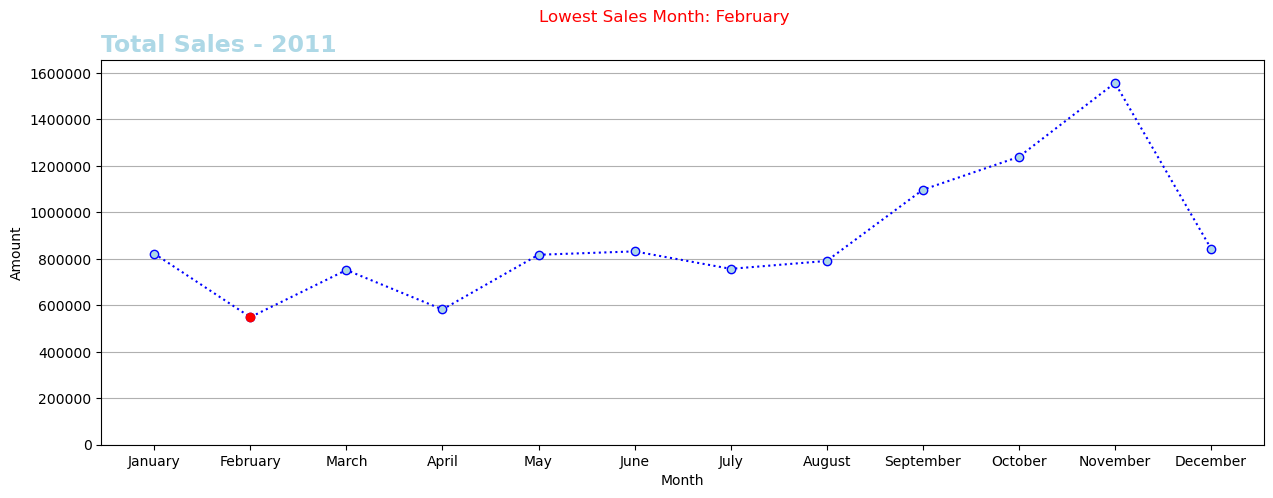

In [3]:
sales_11_df = bm_df[bm_df.Year == 2011]
result_df = sales_11_df.groupby('Month',as_index=False)['Amount'].sum()
result_df['Month'] = pd.Series([dt.datetime.strptime(str(x),'%m').strftime('%B') for x in result_df.Month])
plt.figure(figsize = (15,5))
plt.plot(result_df['Month'],result_df['Amount'],color='blue',linestyle='dotted',marker='o',markerfacecolor='lightblue')
plt.plot(result_df.loc[np.where(result_df['Amount']==min(result_df['Amount']))]['Month'],result_df.loc[np.where(result_df['Amount']==min(result_df['Amount']))]['Amount'],color='red',linestyle='dotted',marker='o',markerfacecolor='red')
plt.title('Total Sales - 2011', fontsize = 17,color='lightblue',weight='bold',loc='left')
plt.suptitle(f"Lowest Sales Month: {result_df.loc[np.where(result_df['Amount']==min(result_df['Amount']))]['Month'][1]}",color='red')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.ticklabel_format(style='plain',axis='y')
plt.grid(True,axis='y')
plt.ylim(0,max(result_df.Amount)+100000)
plt.show()

#### Plot a Pie Chart for the Year 2011 Country Wise. Which Country contributes highest towards sales?

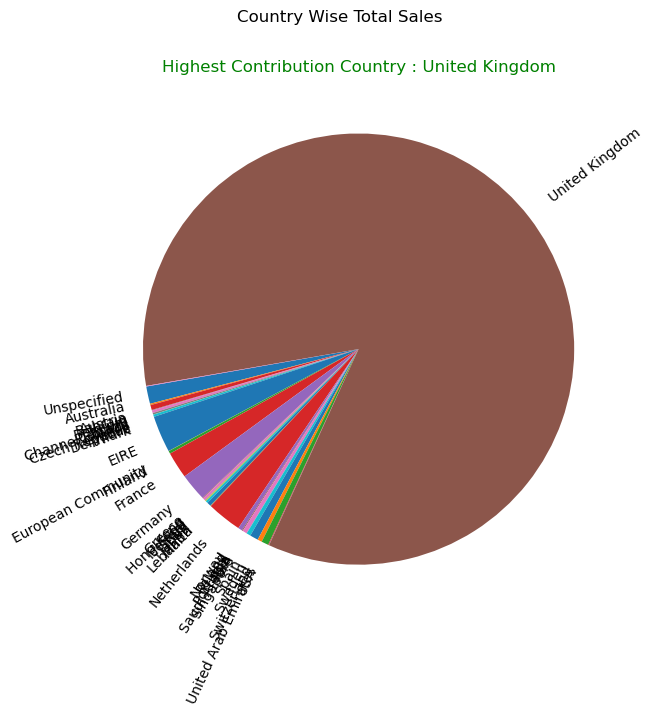

In [4]:
pie_result = sales_11_df.groupby('Country',as_index=False)['Amount'].sum()
plt.figure(figsize = (15,7))
plt.pie(pie_result['Amount'],labels = pie_result['Country'],startangle=190,rotatelabels=True)
plt.suptitle("Country Wise Total Sales")
plt.title(f"Highest Contribution Country : {"".join(list(pie_result.loc[np.where(pie_result['Amount']==max(pie_result['Amount']))]['Country']))}",color="green")
plt.show()

#### Plot Scatter Plot for the invoice amounts and see the concentration of amount.  In which range have most of the invoice amounts concentrated?

In [ ]:
invoice_amounts_df = sales_11_df[['Amount','InvoiceNo','InvoiceDate']].groupby("InvoiceDate",as_index=False).sum()
plt.figure(figsize=(16,5))
plt.scatter(invoice_amounts_df["InvoiceNo"], invoice_amounts_df["Amount"],color="green")
plt.ylim(20000,50000)
plt.show()